<p class="mlx-kicker">Part II &middot; Architecture &middot; Chapter 7</p>

# 7. Residual connections: from highway gates to the residual stream

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 20 min</dd></div><div><dt>Hands-on</dt><dd>about 6 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1, chapter 5 (vanishing gradients), the chain rule</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/ml-explained/blob/main/chapters/07-residual/index.ipynb)

![Three generations of shortcut path. Each column highlights the one part that is new: a learned gate that can carry the input past a layer, a plain identity shortcut with no weights at all, and a clean stream that every Transformer block reads from and adds to.](figures/residual-lineage.svg)

## What changed, and why it works

Chapter 1 removed one part of the Transformer at a time, and removing the residual connections did the most damage by far. This chapter asks why. The guiding question is simple: **why does an identity path make depth trainable?** Each generation in Figure 7.1 gives a sharper answer.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; Highway network</p><h3>A gate that can carry the input past a layer</h3><p><b>What changed.</b> Each layer got a second path that copies its input forward, and a learned sigmoid gate that mixes the layer's output with that copy.</p><p><b>Why it works.</b> A plain deep net struggles to learn "do nothing", because a ReLU layer cannot easily represent the identity. With the gate closed, a highway layer <i>is</i> the identity, so a very deep stack starts out behaving like a shallow one, and the gradient has a route back that skips the layer's weights.</p><p class="mlx-why__run">Our run, 30 layers: plain 2.208, highway 0.116 training loss</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; ResNet</p><h3>An identity shortcut, with no gate</h3><p><b>What changed.</b> The gate was dropped. Each block computes <code>x + F(x)</code>: the input passes through untouched and the layers only learn a correction.</p><p><b>Why it works.</b> The derivative of <code>x + F(x)</code> is the identity plus the derivative of F. However many blocks you stack, the gradient always has one term that reaches the input unchanged, and the blocks start near "do nothing" for free. Unlike the highway gate, the shortcut costs no parameters and can never close.</p><p class="mlx-why__run">Our run, 30 layers: residual 0.085, with the same parameters as the plain net</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; Residual stream</p><h3>A clean stream that blocks read and write</h3><p><b>What changed.</b> Pre-norm Transformers moved the normalization inside each branch, <code>x + f(norm(x))</code>, so the main path is never rescaled. Elhage et al. (2021) then reframed the whole model: one shared vector per token, the residual stream, that every block reads from and adds to.</p><p><b>Why it works.</b> Because nothing on the main path transforms the stream, every block's output reaches every later block and the final head directly. The model behaves like a sum of contributions, so we can decode the stream after any block and watch the prediction form.</p><p class="mlx-why__run">Our runs: no residual 3.368, pre-norm 1.985; at a high learning rate post-norm 3.368, pre-norm 1.974</p></section>
</div>

Read left to right, the shortcut gets simpler (a gate, then no gate, then not even a norm on the path) while its role gets bigger: from a trick for training deep nets to the backbone along which a Transformer does all of its computation. The steps below rebuild each stage and test it.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 1990s-2014 | Plain deep stacks | minor | depth limited to roughly 20 layers in practice; deeper nets trained worse |
| 2015 (May) | Highway networks | minor | a learned gate mixes the layer's output with a copy of its input |
| 2015 (Dec) | ResNet | **major** | an ungated identity shortcut, `x + F(x)`; 152 layers win ImageNet |
| 2016 | Pre-activation ResNet | minor | norm and ReLU move inside the branch, so the shortcut is a pure identity |
| 2017 | Transformer (post-norm) | minor | a residual around every attention and FFN sub-layer, followed by LayerNorm |
| 2019-2020 | Pre-norm residual stream | **major** | `x + f(norm(x))`: GPT-2, Xiong et al.; deep Transformers train without tricks |
| 2021 | Residual-stream view | **major** | Elhage et al.: the stream as a shared channel that blocks read and write |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| plain stack to highway gate | deeper nets trained worse, even on their training data | trainable depth beyond 100 layers |
| highway gate to identity shortcut | gates cost parameters and can close | a free, always-open path; 152 and then 1001 layers |
| post-norm to pre-norm | deep Transformers needed careful warmup and still diverged | stable training at depth, with fewer tricks |
| block diagram to residual-stream view | needing to explain what a trained model computes | a language for interpretability: reads, writes, the logit lens |

The common thread is that each step made the main path *more* boring. The highway gate already showed that the network needs a way to leave its input alone. ResNet removed the gate, and pre-norm removed the last operation on the main path. A boring main path is what lets gradients flow back and what lets each block's contribution survive to the output.

**Still open:** why identity shortcuts help so much more than their gradient arithmetic alone predicts (ensemble and loss-landscape explanations both have support); whether pre-norm wastes depth, because the stream grows and later blocks change it less; and whether richer paths, such as learned mixing between several streams (hyper-connections, 2024), beat the single identity.

## Diverged branches

The evolution path follows the line today's models inherited. At a few points the field split instead: two camps made different bets on the same problem, and sometimes both bets are still alive. Each tab below is one such fork, with the two branches, why they split, and how it has played out so far.

<div class="mlx-why mlx-forks" data-label="Forks in this lineage">
<section class="mlx-why__card mlx-why__card--1 mlx-fork"><p class="mlx-why__n">Fork 1 &middot; 2016-2017</p><h3>Add the input, or concatenate it?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Addition <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p><code>x + F(x)</code>: one fixed-width stream that every layer reads from and adds to.</p><p class="mlx-fork__who">ResNet, every Transformer</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Concatenation <span class="mlx-fork__state mlx-fork__state--niche">niche</span></p><p>Each layer receives the outputs of all earlier layers in its block, stacked side by side.</p><p class="mlx-fork__who">DenseNet</p></div></div><p><b>Why they split.</b> Concatenation keeps every earlier feature intact for reuse, and DenseNet reached ResNet's accuracy with fewer parameters. Addition mixes everything into one stream of fixed width.</p><p><b>How it played out.</b> Addition won. Concatenation makes the width grow with depth, which costs memory, while a fixed-width stream is what lets every Transformer block read and write the same space (step 5). Reaching further back is returning in newer work such as hyper-connections, which learn how to mix several copies of the stream. <strong>[likely]</strong></p></section>
<section class="mlx-why__card mlx-why__card--2 mlx-fork"><p class="mlx-why__n">Fork 2 &middot; 2021-2023</p><h3>Attention then FFN, or both at once?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Sequential block <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>Attention adds to the stream, then the FFN reads the updated stream.</p><p class="mlx-fork__who">the original Transformer, LLaMA, most LLMs</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Parallel block <span class="mlx-fork__state mlx-fork__state--niche">niche</span></p><p><code>x + attn(norm(x)) + ffn(norm(x))</code>: both read the same input, so their input projections can be fused into one matrix multiply.</p><p class="mlx-fork__who">GPT-J, PaLM</p></div></div><p><b>Why they split.</b> The FFN loses the chance to read what attention just wrote, but the block runs faster. PaLM reports roughly 15% faster training at large scale.</p><p><b>How it played out.</b> PaLM found a small quality loss at 8B parameters that disappeared at 62B. Most later open models kept the sequential block, so at their sizes the speedup was not judged worth the risk. <strong>[likely]</strong></p></section>
<section class="mlx-why__card mlx-why__card--3 mlx-fork"><p class="mlx-why__n">Fork 3 &middot; 2016</p><h3>Deeper or wider?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Very deep, thin <span class="mlx-fork__state mlx-fork__state--alive">still used</span></p><p>Keep each layer narrow and stack many: ResNet-152, and a 1001-layer pre-activation ResNet.</p><p class="mlx-fork__who">ResNet, deep LLMs</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Shallower, wide <span class="mlx-fork__state mlx-fork__state--alive">still used</span></p><p>Fewer layers, many more channels per layer. A 16-layer Wide ResNet beat 1000-layer thin ones on CIFAR and trained several times faster.</p><p class="mlx-fork__who">Wide ResNets</p></div></div><p><b>Why they split.</b> If a residual network behaves like an ensemble of mostly short paths (Veit et al., 2016), extra depth may add less than its cost, while width parallelizes well on GPUs.</p><p><b>How it played out.</b> Both survive as knobs. For Transformers, Kaplan et al. (2020) found that loss depends mostly on the total parameter count and only weakly on the depth-to-width ratio across a wide range. <strong>[likely]</strong></p></section>
</div>

## Run it yourself

The first three steps use a small synthetic classification task and deep MLPs, where the degradation problem appears in seconds. The last two return to the chapter 1 Transformer on TinyShakespeare. Every experiment runs on a laptop CPU.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/ml-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import math, time

torch.set_num_threads(1)

# A synthetic task: 4,096 random points in 32 dimensions, labelled into 10 classes
# by a fixed random "teacher" network. Any reasonable net can fit it; the question is
# how well the optimizer finds that fit as the student network gets deeper.
g = torch.Generator().manual_seed(0)
X = torch.randn(4096, 32, generator=g)
W1, W2, W3 = (torch.randn(32, 64, generator=g) / 32**0.5, torch.randn(64, 64, generator=g) / 8,
              torch.randn(64, 10, generator=g) / 8)
Y = (torch.tanh(torch.tanh(X @ W1 * 2) @ W2 * 2) @ W3).argmax(1)
print("examples per class:", torch.bincount(Y).tolist())
print(f"loss of a model that guesses uniformly: ln 10 = {math.log(10):.3f}")

examples per class: [529, 472, 445, 471, 310, 258, 384, 298, 378, 551]
loss of a model that guesses uniformly: ln 10 = 2.303


### Step 1 (major): the degradation problem

#### The problem

By 2015, ReLU, careful initialization and BatchNorm had largely fixed vanishing gradients (chapters 5 and 6). Networks with 20 layers trained well. But He et al. (2015) noticed something odd when they went deeper: a 56-layer plain network had *higher training error* than a 20-layer one on CIFAR-10. This is not overfitting, because overfitting lowers the training error. They called it the **degradation problem**.

The odd part is that the deeper network can represent everything the shallower one can: copy the 20 layers and set the extra 36 to the identity. That solution exists, but the optimizer does not find it. A stack of `ReLU(W x)` layers has no easy way to express "leave the input alone".

#### Minimal implementation

Each layer of our plain network is `ReLU(W LayerNorm(h))`. The normalization is there on purpose: it rules out the trivial explanation that activations simply blow up or die. `DeepMLP` takes a layer class, so later steps can swap in other layers without touching anything else.

In [3]:
class PlainLayer(nn.Module):
    """One layer of a plain deep net: h -> ReLU(W LayerNorm(h))."""

    def __init__(self, width):
        super().__init__()
        self.norm = nn.LayerNorm(width)
        self.lin = nn.Linear(width, width)

    def f(self, h):  # the layer's own transformation, reused by later variants
        return F.relu(self.lin(self.norm(h)))

    def forward(self, h):
        return self.f(h)


class DeepMLP(nn.Module):
    """Input projection, `depth` identical layers, output projection."""

    def __init__(self, depth, layer=PlainLayer, width=64, d_in=32, n_classes=10):
        super().__init__()
        self.inp = nn.Linear(d_in, width)
        self.layers = nn.ModuleList(layer(width) for _ in range(depth))
        self.out = nn.Linear(width, n_classes)

    def forward(self, x):
        h = self.inp(x)
        for layer in self.layers:
            h = layer(h)
        return self.out(h)


def train_mlp(model, steps=800, lr=1e-3, batch=128):
    """Adam on random mini-batches; returns the per-step losses and the final loss on all 4,096 points."""
    torch.manual_seed(0)
    gen = torch.Generator().manual_seed(1)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    curve = []
    for _ in range(steps):
        idx = torch.randint(len(X), (batch,), generator=gen)
        loss = F.cross_entropy(model(X[idx]), Y[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        curve.append(loss.item())
    with torch.no_grad():
        final = F.cross_entropy(model(X), Y).item()
    return {"curve": curve, "final": final}


def smooth(v, k=25):
    return np.convolve(v, np.ones(k) / k, mode="valid")

#### Experiment: deeper plain nets train worse

We train plain networks with 3, 10 and 30 layers on the same data with the same optimizer, and report the **training** loss: how well each network fits the data it is trained on.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">The 30-layer net has ten times the layers of the 3-layer net and can represent any function the 3-layer net can. Will its training loss after 800 steps be lower, about the same, or higher?</p><details><summary>Show what happened</summary><p>Much higher. The 10-layer net fits best (0.319), the 3-layer net is behind (0.420), and the 30-layer net barely learns at all (2.208, against 2.303 for uniform guessing).</p></details></div>

plain     3 layers  final training loss 0.420  (3s)


plain    10 layers  final training loss 0.319  (4s)


plain    30 layers  final training loss 2.208  (11s)


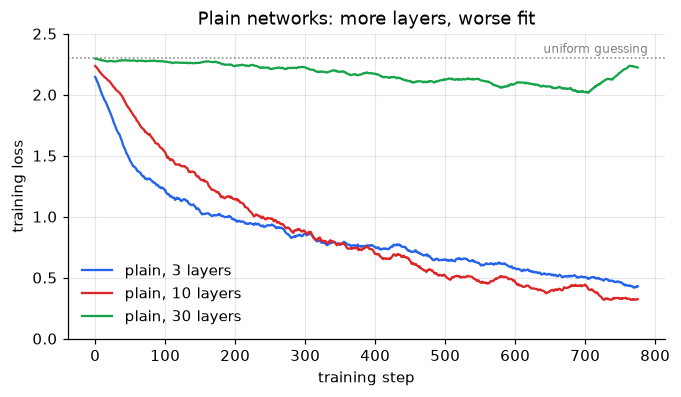

In [4]:
runs = {}
for depth in (3, 10, 30):
    torch.manual_seed(0)
    start = time.time()
    runs[("plain", depth)] = train_mlp(DeepMLP(depth, PlainLayer))
    print(f"plain    {depth:2d} layers  final training loss {runs[('plain', depth)]['final']:.3f}  ({time.time() - start:.0f}s)")

fig, ax = plt.subplots(figsize=(7, 3.6))
for depth in (3, 10, 30):
    ax.plot(smooth(runs[("plain", depth)]["curve"]), label=f"plain, {depth} layers")
ax.axhline(math.log(10), color="gray", ls=":", lw=1)
ax.text(790, math.log(10) + 0.04, "uniform guessing", ha="right", fontsize=8, color="gray")
ax.set(xlabel="training step", ylabel="training loss", title="Plain networks: more layers, worse fit", ylim=(0, 2.5))
ax.legend(frameon=False);

Where does the signal go wrong? Chapter 5 measured the gradient reaching each layer, so let us do the same for the 30-layer plain net at initialization.

In [5]:
def grad_per_layer(model, n=512):
    """Gradient norm of each layer's weight matrix for one batch at initialization."""
    model.zero_grad()
    F.cross_entropy(model(X[:n]), Y[:n]).backward()
    return [layer.lin.weight.grad.norm().item() for layer in model.layers]


torch.manual_seed(0)
g_plain = grad_per_layer(DeepMLP(30, PlainLayer))
print(f"plain, 30 layers: first layer {g_plain[0]:.2f}, last layer {g_plain[-1]:.3f}, ratio {g_plain[0] / g_plain[-1]:.0f}x")

plain, 30 layers: first layer 53.72, last layer 0.143, ratio 376x


The gradient does not vanish. It is *larger* near the input, by about 376 times. So the textbook explanation from chapter 5 is not what is happening here; the normalization layers keep the signal alive. What breaks is subtler: after 30 random ReLU layers, the gradient at the early layers is large but close to noise, because tiny changes in the input of a long chain of nonlinear layers flip which units are active. Balduzzi et al. (2017) called this **shattered gradients**: the gradients of neighbouring inputs become nearly uncorrelated, so a step that helps one example tells you little about the next. **[likely]**

#### Why it failed: a post-mortem

**Deeper plain nets fit worse, even on their own training data.** This is He et al.'s observation, and our 30-layer net shows it in an extreme form. **[established]**

**It is an optimization problem, not a capacity problem.** The 30-layer net could copy the 10-layer solution and pass the rest through, but finding "pass it through" with ReLU layers means learning a precise weight matrix in every extra layer. **[established]** for the existence argument; **[likely]** that this is the main obstacle.

**The gradient is not small, it is unhelpful.** With normalization in place, gradient norms stay large; what degrades with depth is how useful the gradient direction is. **[likely]**, following Balduzzi et al. (2017).

### Step 2 (minor): highway networks

Srivastava, Greff and Schmidhuber (2015) borrowed an idea from the LSTM (chapter 4): let a learned gate decide how much of each unit to update and how much to carry over unchanged. A **highway layer** computes the usual transformation `H(x)`, a gate `T(x) = sigmoid(W_T x + b)`, and mixes them.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: the highway layer</p><div class="mlx-eq">$$y = T(x)\odot H(x) + \big(1 - T(x)\big)\odot x, \qquad T(x) = \sigma(W_T x + b_T)$$</div><p class="mlx-eq__where">With \(b_T\) initialized negative (we use \(-2\), so \(T \approx 0.12\)), every layer starts out mostly copying its input. The paper recommends this bias to make very deep highway nets trainable.</p></div>

The gate doubles the parameters of each layer. Highway networks were trained with up to 100 layers, then a striking depth, and the same gated design was used in speech and language models soon after.

In [6]:
class HighwayLayer(PlainLayer):
    """y = T * H(x) + (1 - T) * x, with a learned sigmoid gate T per unit."""

    def __init__(self, width, gate_bias=-2.0):
        super().__init__(width)
        self.gate = nn.Linear(width, width)
        nn.init.constant_(self.gate.bias, gate_bias)  # start mostly carrying the input

    def forward(self, h):
        t = torch.sigmoid(self.gate(h))
        self.last_gate = t.mean().item()  # for inspection only
        return t * self.f(h) + (1 - t) * h


torch.manual_seed(0)
highway = DeepMLP(30, HighwayLayer)
start = time.time()
runs[("highway", 30)] = train_mlp(highway)
print(f"highway  30 layers  final training loss {runs[('highway', 30)]['final']:.3f}  ({time.time() - start:.0f}s)")
print(f"plain    30 layers  final training loss {runs[('plain', 30)]['final']:.3f}")

with torch.no_grad():
    highway(X)
gates = [layer.last_gate for layer in highway.layers]
print("mean gate T after training, every 5th layer:", [f"{t:.2f}" for t in gates[::5]])

highway  30 layers  final training loss 0.116  (24s)
plain    30 layers  final training loss 2.208
mean gate T after training, every 5th layer: ['0.13', '0.12', '0.12', '0.12', '0.14', '0.16']


The same 30-layer depth that failed as a plain stack now fits the data well (0.116 against 2.208). After training, the mean gate values we printed stay between 0.12 and 0.16: every layer still carries most of its input forward and adds only a fraction of its own output. The net has learned to use depth gently. It is slower, though: the gates double the matrix multiplications per layer. **[established]** that gating makes depth trainable; the gate values are from our run.

### Step 3 (major): ResNet's identity shortcut

#### The idea

He et al. (2015) asked a simpler question: if the extra layers should start as the identity, why not build the identity in? A **residual block** computes `y = x + F(x)`. There is no gate and no weights on the shortcut. The layers inside `F` only learn the *residual*, the difference between the desired output and the input, and if the best thing is to do nothing, `F = 0` is easy to reach: just shrink the weights.

The gradient tells the same story. Unroll a stack of residual blocks and differentiate the output with respect to an early block's input:

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: the gradient through residual blocks</p><div class="mlx-eq">$$x_{l+1} = x_l + F_l(x_l) \quad\Longrightarrow\quad \frac{\partial x_L}{\partial x_l} = \prod_{k=l}^{L-1}\Big(I + \frac{\partial F_k}{\partial x_k}\Big) = I + \sum_{k} \frac{\partial F_k}{\partial x_k} + \dots$$</div><p class="mlx-eq__where">Expanding the product gives one term, \(I\), that carries the gradient back untouched, plus terms that pass through one block, two blocks, and so on. In a plain stack only the last, longest product exists. He et al. (2016) built on this to train a 1001-layer network.</p></div>

Veit et al. (2016) read the same expansion another way: a residual network behaves like an ensemble of many paths of different lengths, and most of the gradient during training flows through the *short* ones. Deleting a single block from a trained ResNet barely hurts it, while deleting a layer from a plain net destroys it. **[likely]**

#### Minimal implementation

Our block keeps the normalization inside the branch, `h + ReLU(W LayerNorm(h))`. This is the "pre-activation" layout of He et al. (2016) rather than the original ResNet, which put a ReLU after the addition; we use it because it is also the layout of a pre-norm Transformer (step 4).

In [7]:
class ResidualLayer(PlainLayer):
    """y = x + F(x): the identity shortcut, no gate and no extra parameters."""

    def forward(self, h):
        return h + self.f(h)


for depth in (3, 10, 30):
    torch.manual_seed(0)
    start = time.time()
    runs[("residual", depth)] = train_mlp(DeepMLP(depth, ResidualLayer))
    print(f"residual {depth:2d} layers  final training loss {runs[('residual', depth)]['final']:.3f}  ({time.time() - start:.0f}s)")

residual  3 layers  final training loss 0.649  (2s)


residual 10 layers  final training loss 0.069  (4s)


residual 30 layers  final training loss 0.085  (12s)


#### Experiment: the same depths, with and without the shortcut

The residual nets have exactly the same parameters as the plain nets above; only the `h +` is new.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">With the identity shortcut, does the 30-layer net now beat the 10-layer one? And how does the gradient per layer at initialization compare with the plain net's?</p><details><summary>Show what happened</summary><p>The 10- and 30-layer residual nets both fit the data well (0.069 and 0.085). The 30-layer net no longer collapses; across three seeds it is about as good as the 10-layer one (better in two seeds, worse in this one). At initialization the residual net's gradients differ by only about 2.3&times; between the first and last layer, against 376&times; for the plain net.</p></details></div>

residual, 30 layers: first / last layer gradient = 2.3x (plain: 376x)


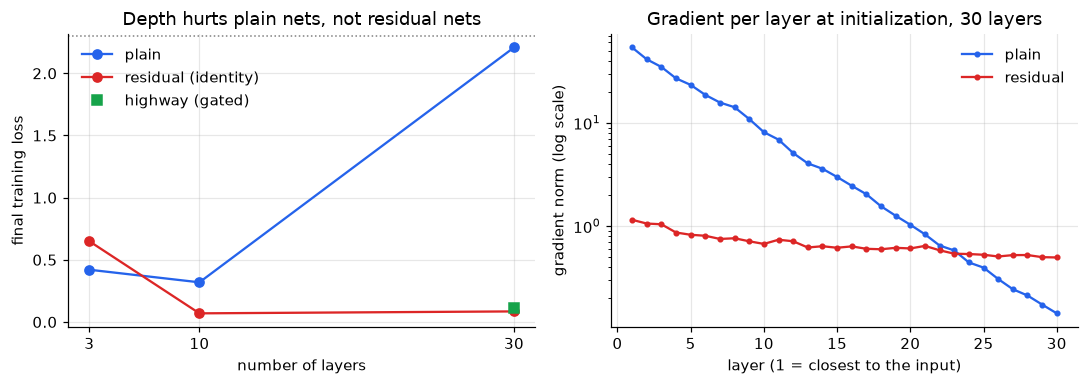

In [8]:
torch.manual_seed(0)
g_res = grad_per_layer(DeepMLP(30, ResidualLayer))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
depths = [3, 10, 30]
ax1.plot(depths, [runs[("plain", d)]["final"] for d in depths], "o-", label="plain")
ax1.plot(depths, [runs[("residual", d)]["final"] for d in depths], "o-", label="residual (identity)")
ax1.plot([30], [runs[("highway", 30)]["final"]], "s", color="#16a34a", label="highway (gated)")
ax1.axhline(math.log(10), color="gray", ls=":", lw=1)
ax1.set(xlabel="number of layers", ylabel="final training loss", title="Depth hurts plain nets, not residual nets", xticks=depths)
ax1.legend(frameon=False)
ax2.semilogy(range(1, 31), g_plain, "o-", ms=3, label="plain")
ax2.semilogy(range(1, 31), g_res, "o-", ms=3, label="residual")
ax2.set(xlabel="layer (1 = closest to the input)", ylabel="gradient norm (log scale)", title="Gradient per layer at initialization, 30 layers")
ax2.legend(frameon=False)
plt.tight_layout()
print(f"residual, 30 layers: first / last layer gradient = {g_res[0] / g_res[-1]:.1f}x (plain: {g_plain[0] / g_plain[-1]:.0f}x)")

#### Why it worked: a post-mortem

**The shortcut removes the degradation problem.** With the identity path, the 30-layer net trains almost as well as the 10-layer one (0.085 against 0.069), instead of failing outright (2.208). Both beat the 3-layer net, which simply lacks capacity. Depth stops being a liability, though on a task this small it is not yet an asset. This is the central result of He et al. (2015), who trained 152 layers on ImageNet and over 1000 on CIFAR-10. **[established]**

**The gradient is balanced across depth.** Every layer receives a gradient of similar size, because each one has a direct path to the loss through the identity terms. **[established]** as arithmetic; whether balanced gradient *norms* are the whole story is less clear, since the plain net's gradients were large too.

**Starting near the identity is what matters.** Each residual block begins as a small perturbation of its input, so the 30-layer net starts out behaving like a well-conditioned shallow net and grows into its depth. Highway networks get the same effect from a closed gate; ResNet gets it for free. Later work made this explicit by initializing the last layer of each branch at zero (Goyal et al., 2017; ReZero, 2020). **[likely]** as the main mechanism.

**Gate versus identity.** In our run the identity beats the gate at 30 layers (0.085 against 0.116) at half the cost per layer. He et al. argued that a gate can close and block the shortcut, while the identity is always open. Highway networks were also strong at moderate depth, so the gap is in simplicity and in very deep regimes more than at 30 layers. **[likely]**

### Step 4 (major): the residual stream in a Transformer

#### The idea

The original Transformer (Vaswani et al., 2017) wrapped each attention and feed-forward sub-layer in a residual connection, then normalized: `x = LayerNorm(x + f(x))`. This **post-norm** layout puts a normalization *on the main path*, so the shortcut is no longer a pure identity: every sub-layer rescales everything that came before it. In practice, deep post-norm Transformers needed a learning-rate warmup to train at all, and still diverged at depth (Xiong et al., 2020; Liu et al., 2020).

GPT-2 (2019) and most models since use **pre-norm**: `x = x + f(norm(x))`. The norm moves into the branch, so the main path from the embedding to the output head is a plain sum. That sum is what Elhage et al. (2021) named the **residual stream**.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equations: post-norm and pre-norm</p><div class="mlx-eq">$$\text{post-norm: } x_{l+1} = \mathrm{Norm}\big(x_l + f_l(x_l)\big) \qquad \text{pre-norm: } x_{l+1} = x_l + f_l\big(\mathrm{Norm}(x_l)\big)$$</div><p class="mlx-eq__where">Unrolled, pre-norm gives \(x_L = x_0 + \sum_l f_l(\cdot)\): the stream is the embedding plus every block's write. Post-norm has no such sum, because each Norm rescales the history.</p></div>

#### Minimal implementation

`mlexp`'s `Block` is already pre-norm, and `residual=False` removes the shortcuts (chapter 1). We only need to write a post-norm block.

In [9]:
from mlexp.transformer import Attention, RMSNorm, SwiGLU, TransformerLM

tok, train_ids, val_ids = mlexp.load_char_corpus()


class PostNormBlock(nn.Module):
    """The 2017 layout: add the sub-layer's output, then normalize the stream itself."""

    def __init__(self, dim, n_heads):
        super().__init__()
        self.attn, self.ffn = Attention(dim, n_heads), SwiGLU(dim)
        self.norm1, self.norm2 = RMSNorm(dim), RMSNorm(dim)

    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        return self.norm2(x + self.ffn(x))


def build_lm(variant, n_layers=6, dim=64):
    torch.manual_seed(0)
    model = TransformerLM(tok.vocab_size, dim=dim, n_layers=n_layers, n_heads=4,
                          residual=(variant != "no residual"))
    if variant == "post-norm":
        model.blocks = nn.ModuleList(PostNormBlock(dim, 4) for _ in range(n_layers))
    return model

#### Experiment: no residual, post-norm, pre-norm

We train a 6-block model three times for 300 steps: without residual connections, with the 2017 post-norm layout, and with today's pre-norm layout. This is a smaller and shorter version of chapter 1's ablation, where removing residuals raised the validation loss from 1.74 to 3.35.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">Removing the residuals will clearly hurt. But between post-norm and pre-norm, which reaches the lower validation loss with the default recipe? And which survives a learning rate ten times higher with no warmup?</p><details><summary>Show what happened</summary><p>Without residuals the model stalls at 3.368, near a model that only knows character frequencies. With the default recipe post-norm (1.951) slightly <i>beats</i> pre-norm (1.985). Under the harsh schedule, post-norm collapses (3.368) while pre-norm still learns (1.974).</p></details></div>

no residual  final val loss 3.368  (60s)


post-norm    final val loss 1.951  (52s)


pre-norm     final val loss 1.985  (54s)


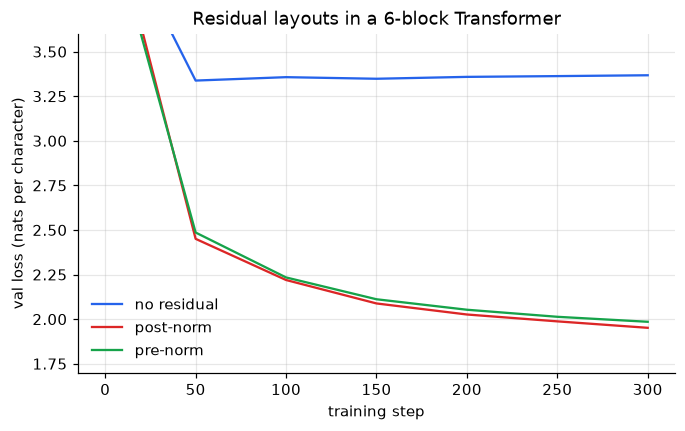

In [10]:
lm_hist, lms = {}, {}
for variant in ["no residual", "post-norm", "pre-norm"]:
    lms[variant] = build_lm(variant)
    start = time.time()
    lm_hist[variant] = mlexp.train_lm(lms[variant], train_ids, val_ids, steps=300, block_size=64, eval_every=50, log=False)
    print(f"{variant:12s} final val loss {lm_hist[variant]['val'][-1]:.3f}  ({time.time() - start:.0f}s)")

ax = mlexp.plot_histories(lm_hist, "Residual layouts in a 6-block Transformer")
ax.set_ylim(1.7, 3.6);

Post-norm trains fine here, and even slightly better. The textbook claim is about stability, not final quality, so we stress both layouts: a peak learning rate ten times higher (3e-2) and no warmup at all.

post-norm  lr 3e-2, no warmup: final val loss 3.368  (56s)


pre-norm   lr 3e-2, no warmup: final val loss 1.974  (58s)


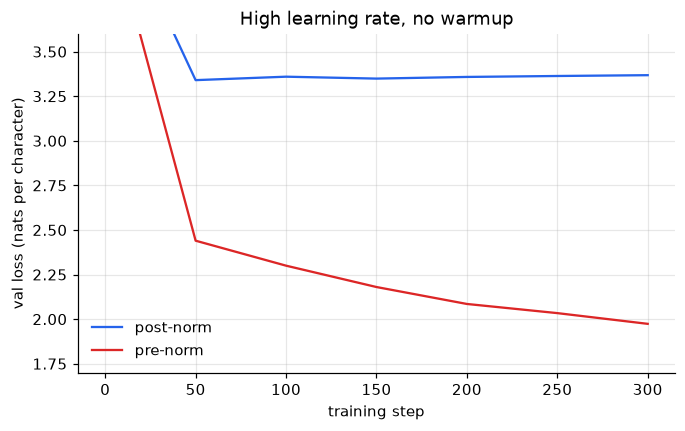

In [11]:
hot_hist = {}
for variant in ["post-norm", "pre-norm"]:
    start = time.time()
    hot_hist[variant] = mlexp.train_lm(build_lm(variant), train_ids, val_ids, steps=300, block_size=64, eval_every=50,
                                       lr=3e-2, warmup_frac=0.0, log=False)
    print(f"{variant:10s} lr 3e-2, no warmup: final val loss {hot_hist[variant]['val'][-1]:.3f}  ({time.time() - start:.0f}s)")

ax = mlexp.plot_histories(hot_hist, "High learning rate, no warmup")
ax.set_ylim(1.7, 3.6);

Now the textbook story appears: under the harsher schedule pre-norm still learns (1.974), while post-norm collapses to 3.368, no better than the model without residuals. A last probe shows what is structurally different between the two: how large the stream is after each block, and how much of the original token embedding is still in it.

post-norm  stream RMS by layer [0.95, 0.97, 0.97, 0.97, 0.97, 0.98, 0.96]
           cosine with the embedding [1.0, 0.82, 0.64, 0.49, 0.38, 0.25, 0.2]
pre-norm   stream RMS by layer [0.94, 1.12, 1.35, 1.59, 1.83, 2.15, 2.67]
           cosine with the embedding [1.0, 0.82, 0.63, 0.5, 0.4, 0.31, 0.25]


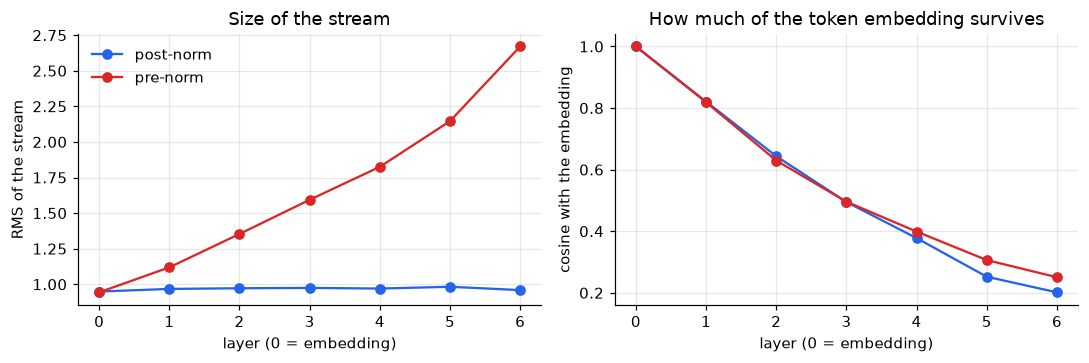

In [12]:
@torch.no_grad()
def stream_states(model, x):
    """The residual stream after the embedding and after every block."""
    states = [model.embed(x)]
    for block in model.blocks:
        states.append(block(states[-1]))
    return states


xb, yb = mlexp.get_batch(val_ids, 32, 64, torch.Generator().manual_seed(0))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
for variant in ["post-norm", "pre-norm"]:
    states = stream_states(lms[variant], xb)
    rms = [s.pow(2).mean().sqrt().item() for s in states]
    cos = [F.cosine_similarity(s, states[0], dim=-1).mean().item() for s in states]
    ax1.plot(rms, "o-", label=variant)
    ax2.plot(cos, "o-", label=variant)
    print(f"{variant:10s} stream RMS by layer {[round(r, 2) for r in rms]}")
    print(f"{'':10s} cosine with the embedding {[round(c, 2) for c in cos]}")
ax1.set(xlabel="layer (0 = embedding)", ylabel="RMS of the stream", title="Size of the stream")
ax2.set(xlabel="layer (0 = embedding)", ylabel="cosine with the embedding", title="How much of the token embedding survives")
ax1.legend(frameon=False)
plt.tight_layout()

#### Why it worked: a post-mortem

**Without residuals the Transformer barely trains.** The loss stays near 3.368, roughly what a model that predicts characters by frequency alone achieves. Six blocks of attention and FFN with nothing to carry the input forward already behave like the 30-layer plain MLP of step 1. **[established]**

**Post-norm can match or beat pre-norm when it trains.** With gradient clipping, warmup and only six blocks, post-norm is safe, and it edges ahead. That is consistent with Liu et al. (2020), who found that post-norm, once it trains, often ends slightly better, because each block's output is not diluted by an ever-larger stream. **[likely]**: post-norm was ahead in all three seeds we ran, but by as little as 0.003 in one of them.

**Pre-norm buys stability.** Under a ten times higher learning rate with no warmup, post-norm fails completely and pre-norm does not. Xiong et al. (2020) traced this to the gradients at initialization: in post-norm, the gradient reaching the last layers is large, so early large steps break the model, and warmup exists to keep those first steps small. Pre-norm keeps a clean identity path from the loss to every block, so no layer receives an outsized gradient. This is why GPT-2 and almost every large model since use pre-norm. **[established]**

**The two layouts treat the stream differently.** In pre-norm the stream keeps growing, from RMS 0.94 at the embedding to 2.67 after six blocks, because each block adds to it and nothing shrinks it. In post-norm it is rescaled to RMS 1 after every sub-layer. In both, the stream's similarity to the original embedding falls at about the same rate (to 0.25 in pre-norm and 0.20 in post-norm), so "clean path" does not mean the input survives unchanged: the blocks write large updates. Pre-norm's growing stream is its known weakness: later blocks must write ever larger updates to have the same effect, so deep pre-norm models may use their last layers less. **[likely]**

### Step 5 (minor): the residual-stream view and the logit lens

Elhage et al. (2021) proposed reading a pre-norm Transformer as a **communication channel**. Each token has one vector, the stream. Every attention head and every FFN *reads* from it (through a norm and a projection) and *writes* back by adding. Nothing else touches it. Because the output head reads the final stream through one last norm, any block's write is, in effect, a direct vote on the next token, plus whatever later blocks do with it.

This suggests a simple probe, the **logit lens** (nostalgebraist, 2020): apply the final norm and output head to the stream *after each block*, as if the model stopped there. If the stream really is a shared workspace, these early decodings should already be sensible and should sharpen block by block.

pre-norm logit lens, loss after each block: [4.04, 2.98, 2.7, 2.56, 2.4, 2.29, 2.04]


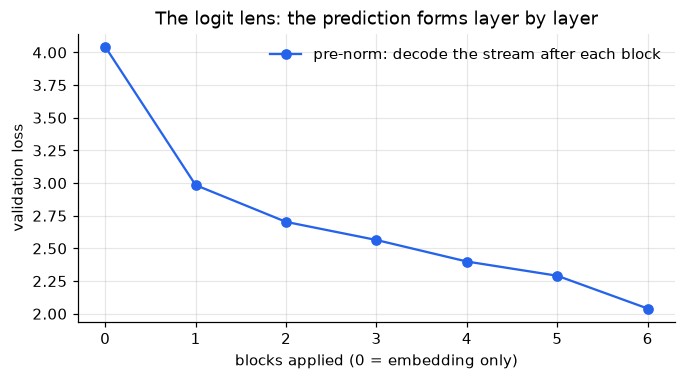

In [13]:
@torch.no_grad()
def logit_lens(model, x, y):
    """Validation loss when the stream after each block is decoded with the final norm and head."""
    losses = []
    for state in stream_states(model, x):
        logits = model.head(model.norm(state))
        losses.append(F.cross_entropy(logits.flatten(0, 1), y.flatten()).item())
    return losses


lens = logit_lens(lms["pre-norm"], xb, yb)
print("pre-norm logit lens, loss after each block:", [round(v, 2) for v in lens])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(lens, "o-", label="pre-norm: decode the stream after each block")
ax.set(xlabel="blocks applied (0 = embedding only)", ylabel="validation loss", title="The logit lens: the prediction forms layer by layer", xticks=range(7))
ax.legend(frameon=False);

In [14]:
# What does the model predict next, for each position of a phrase, as the stream passes each block?
phrase = "ROMEO:\nWhat is th"
ids = tok.encode(phrase)[None]
model = lms["pre-norm"]
with torch.no_grad():
    states = stream_states(model, ids)
print("position:  " + "".join(f"{repr(c)[1:-1]:>4}" for c in phrase[-8:]))
for layer, state in enumerate(states):
    top = model.head(model.norm(state))[0, -8:].argmax(-1)
    print(f"block {layer}:   " + "".join(f"{repr(tok.decode([int(t)]))[1:-1]:>4}" for t in top))

position:     a   t       i   s       t   h
block 0:      g   e   b   &   h   b   e   e
block 1:      n   h   w   c   t   w   h   e
block 2:      t   h   t   n   t   t   h   e
block 3:      t   h   t   t   t   t   h   e
block 4:      t       t   t   t   t   h   e
block 5:      t       t   n       t   h   e
block 6:      t       t   n       t   h   e


The loss falls at every block, from 4.04 to 2.04. The embedding alone decodes to almost nothing useful (4.04 is close to uniform guessing over 65 characters, ln 65 = 4.17): the head was trained to read the finished stream, not the raw embedding, and the two are not aligned. From block 2 on, the decoded guesses are already sensible: "t" followed by "h", "h" followed by "e". Later blocks mostly fix details that need more context, such as predicting a space after "at" (block 4) and after "is" (block 5). The last row is the model's real prediction. This step-by-step refinement is what the residual-stream picture predicts: no block rebuilds the representation, each one edits it. **[established]** for this kind of probe in large models (nostalgebraist, 2020; Belrose et al., 2023, who trained a small "tuned lens" per layer because the raw logit lens is biased in early layers); our tiny model shows the same shape.

The view has costs. It treats the stream as a linear space with many features in superposition, and decoding it with the final head is only an approximation for middle layers. **[likely]** Still, it changed how people study Transformers: induction heads, feature circuits and sparse autoencoders all start from the stream. **[established]** as a research practice.

## Across three seeds

The numbers on this page come from one run, seed 0. We reran the whole notebook twice more with every random seed shifted by 1 and by 2, which changes the initial weights, the batches and the evaluation samples (the `Seed runs` workflow in the repository does this for any chapter). A gap between two runs means something only when it is clearly larger than their spread.

| Run | This page (seed 0) | Mean ± sd, 3 seeds | Seeds 0 / 1 / 2 |
| --- | --- | --- | --- |
| plain, 10 layers (training loss) | 0.319 | 0.314 ± 0.018 | 0.319 / 0.328 / 0.294 |
| plain, 30 layers | 2.208 | 2.147 ± 0.094 | 2.208 / 2.039 / 2.195 |
| highway, 30 layers | 0.116 | 0.114 ± 0.002 | 0.116 / 0.113 / 0.112 |
| residual, 10 layers | 0.069 | 0.073 ± 0.021 | 0.069 / 0.096 / 0.054 |
| residual, 30 layers | 0.085 | 0.052 ± 0.030 | 0.085 / 0.044 / 0.027 |
| Shakespeare, no residual | 3.368 | 3.356 ± 0.011 | 3.368 / 3.351 / 3.348 |
| Shakespeare, post-norm | 1.951 | 1.971 ± 0.020 | 1.951 / 1.972 / 1.990 |
| Shakespeare, pre-norm | 1.985 | 1.989 ± 0.004 | 1.985 / 1.988 / 1.993 |
| lr 0.03, no warmup: post-norm | 3.368 | 3.356 ± 0.010 | 3.368 / 3.351 / 3.349 |
| lr 0.03, no warmup: pre-norm | 1.974 | 1.989 ± 0.013 | 1.974 / 1.998 / 1.996 |

All the large effects held. The two small ones are worth reading carefully: the 30- and 10-layer residual nets swap places between seeds, and post-norm's edge over pre-norm ranged from 0.003 to 0.034.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Describe the degradation problem and show it in a deep plain network.</li><li>Write the highway layer and the residual block, and explain why the identity path keeps gradients balanced across depth.</li><li>Tell post-norm from pre-norm, and say what each does to the residual stream.</li><li>Use the logit lens to watch a prediction form block by block.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>A 30-layer plain net has higher <i>training</i> loss than a 10-layer one. Why is this not overfitting, and why is it surprising?</summary><p>Overfitting means fitting the training data too well, so training loss would be lower, not higher. It is surprising because the deeper net can represent the shallower net's solution, by setting its extra layers to the identity. The optimizer simply fails to find it.</p></details><details><summary>Differentiate x + F(x) with respect to x. Why does this help a deep stack?</summary><p>The derivative is I + dF/dx. Multiplied over many blocks, the product always contains the identity term, so part of the gradient reaches every block unchanged, however deep the stack is.</p></details><details><summary>Why is the shortcut in a post-norm Transformer not a pure identity?</summary><p>Post-norm computes Norm(x + f(x)). The normalization sits on the main path, so every sub-layer rescales the whole stream, including everything earlier blocks wrote. Pre-norm, x + f(Norm(x)), leaves the main path untouched.</p></details></div>

## Further reading

- Srivastava, Greff and Schmidhuber, 2015, [Highway Networks](https://arxiv.org/abs/1505.00387) and [Training Very Deep Networks](https://arxiv.org/abs/1507.06228).
- He, Zhang, Ren and Sun, 2015, [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385): the degradation problem and ResNet.
- He, Zhang, Ren and Sun, 2016, [Identity Mappings in Deep Residual Networks](https://arxiv.org/abs/1603.05027): pre-activation blocks, 1001 layers.
- Veit, Wilber and Belongie, 2016, [Residual Networks Behave Like Ensembles of Relatively Shallow Networks](https://arxiv.org/abs/1605.06431).
- Balduzzi et al., 2017, [The Shattered Gradients Problem: If resnets are the answer, then what is the question?](https://arxiv.org/abs/1702.08591).
- Xiong et al., 2020, [On Layer Normalization in the Transformer Architecture](https://arxiv.org/abs/2002.04745): post-norm versus pre-norm.
- Elhage et al., 2021, [A Mathematical Framework for Transformer Circuits](https://transformer-circuits.pub/2021/framework/index.html): the residual-stream view.
- nostalgebraist, 2020, [interpreting GPT: the logit lens](https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens); Belrose et al., 2023, [Eliciting Latent Predictions from Transformers with the Tuned Lens](https://arxiv.org/abs/2303.08112).
- Huang et al., 2016, [Densely Connected Convolutional Networks](https://arxiv.org/abs/1608.06993).
- Zhu et al., 2024, [Hyper-Connections](https://arxiv.org/abs/2409.19606).
- Chowdhery et al., 2022, [PaLM: Scaling Language Modeling with Pathways](https://arxiv.org/abs/2204.02311): the parallel block.
- Zagoruyko and Komodakis, 2016, [Wide Residual Networks](https://arxiv.org/abs/1605.07146).
- Kaplan et al., 2020, [Scaling Laws for Neural Language Models](https://arxiv.org/abs/2001.08361).